# Module 4, Assignment 1: Linear Regression (Supervised Learning)

# Part 1: Predicting Life Expectancy in the United States
We often take data for granted. However, one of the hardest parts about analyzing a problem you're interested in can be to find good data to answer the questions you want to ask. There are a few resources of which you can easily access from, including the R data repository and Kaggle.

In this problem, we will be examining the "state" dataset from R, which has data from the 1970s on all fifty US states. For each state, the dataset includes the population, per capita income, illiteracy rate, murder rate, high school graduation rate, average number of frost days, area, latitude and longitude, division the state belongs to,  region the state belongs to, and two-letter abbreviation.


We have pre-downloaded the CSV file with the same data that you can load into Python using the read_csv function: statedata.csv

After you have loaded the data into R, inspect the data set using the command: info()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

# Load statedata.csv
df_state = pd.read_csv("statedata.csv")
print(df_state.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Population      50 non-null     int64  
 1   Income          50 non-null     int64  
 2   Illiteracy      50 non-null     float64
 3   Life.Exp        50 non-null     float64
 4   Murder          50 non-null     float64
 5   HS.Grad         50 non-null     float64
 6   Frost           50 non-null     int64  
 7   Area            50 non-null     int64  
 8   state.abb       50 non-null     object 
 9   state.area      50 non-null     int64  
 10  x               50 non-null     float64
 11  y               50 non-null     float64
 12  state.division  50 non-null     object 
 13  state.name      50 non-null     object 
 14  state.region    50 non-null     object 
dtypes: float64(6), int64(5), object(4)
memory usage: 6.0+ KB
None


This dataset has 50 observations (one for each US state) and the following 15 variables:

* **Population** - the population estimate of the state in 1975
* **Income** - per capita income in 1974
* **Illiteracy** - illiteracy rates in 1970, as a percent of the population
* **Life.Exp** - the life expectancy in years of residents of the state in 1970
* **Murder** - the murder and non-negligent manslaughter rate per 100,000 population in 1976
* **HS.Grad** - percent of high-school graduates in 1970
* **Frost** - the mean number of days with minimum temperature below freezing from 1931–1960 in the capital or a large city of the state
* **Area** - the land area (in square miles) of the state
* **state.abb** - a 2-letter abreviation for each state
* **state.area** - the area of each state, in square miles
* **x** - the longitude of the center of the state
* **y** - the latitude of the center of the state
* **state.division** - the division each state belongs to (New England, Middle Atlantic, South Atlantic, East South Central, West South Central, East North Central, West North Central, Mountain, or Pacific)
* **state.name** - the full names of each state
* **state.region** - the region each state belong to (Northeast, South, North Central, or West)

In [2]:
# Now let's look at some summary statistics divided by regions.
# Summary statistics
grouped = df_state.groupby("state.region")["HS.Grad"].mean()
print(grouped)

state.region
North Central    54.516667
Northeast        53.966667
South            44.343750
West             62.000000
Name: HS.Grad, dtype: float64


## Data Exploration

We begin by exploring the data. Plot all of the states' centers with latitude on the y-axis (the "y" variable in our dataset) and longitude on the x-axis (the "x" variable in our dataset) using the Matplotlib library's scatter command. The shape of the plot should look like the outline of the United States! Note that Alaska and Hawaii have had their coordinates adjusted to appear just off of the West Coast.

In the Python command you used to generate this plot, which variable name did you use as the first argument?

*   df_state["y"]
*   df_state["x"]
*   I used a different variable name.


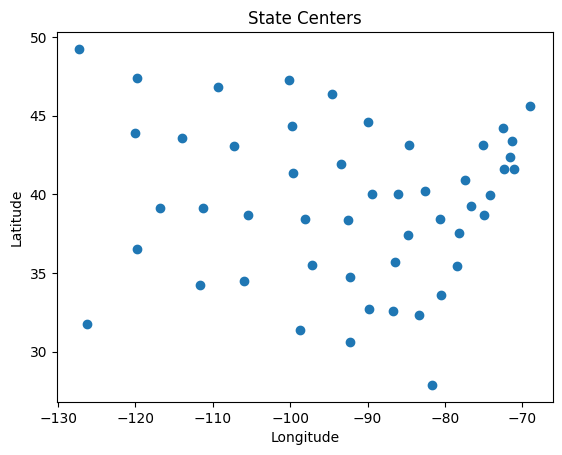

In [3]:
# Answer key:
# Scatter plot of state centers
plt.scatter(df_state["x"], df_state["y"])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("State Centers")
plt.show()

Now, make a boxplot of the murder rate by region. Which region has the highest median murder rate?


*   Northeast
*   South
*   North Central
*   West

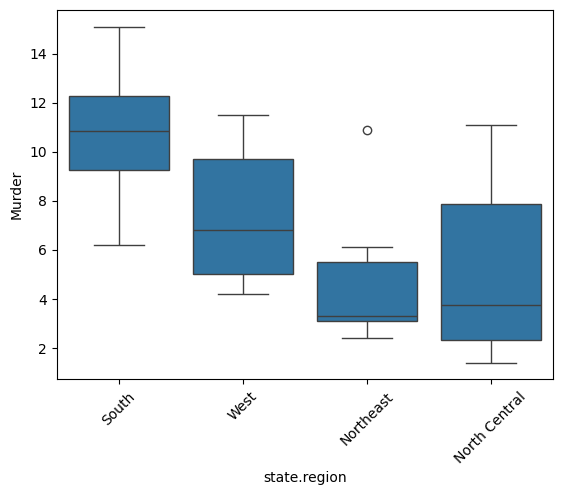

In [4]:
# Boxplot of murder rate by region
sns.boxplot(x="state.region", y="Murder", data=df_state)
plt.xticks(rotation=45)
plt.show()

You should see that there is an outlier in the Northeast region of the boxplot you just generated. Which state does this correspond to? (Hint: There are many ways to find the answer to this question, but one way is to use the boolean subsetting command to only look at the Northeast data.)



*   Delaware
*   Rhode Island
*   Maine
*   New York

In [5]:
# Subset where murder rate is greater than 10 in Northeast
subset_high_murder = df_state[(df_state["state.region"] == "Northeast") & (df_state["Murder"] > 10)]
print(subset_high_murder)

    Population  Income  Illiteracy  Life.Exp  Murder  HS.Grad  Frost   Area  \
31       18076    4903         1.4     70.55    10.9     52.7     82  47831   

   state.abb  state.area        x        y   state.division state.name  \
31        NY       49576 -75.1449  43.1361  Middle Atlantic   New York   

   state.region  
31    Northeast  


Another important aspect of the features included is correlations among the features. We see that compared to itself every feature has a correlation of 1.

In [6]:
var_numeric = ["Population", "Income", "Illiteracy", "Life.Exp", "Murder", "HS.Grad", "Frost", "Area"]
df_numeric = df_state[var_numeric]
print(df_numeric.corr())

            Population    Income  Illiteracy  Life.Exp    Murder   HS.Grad  \
Population    1.000000  0.208228    0.107622 -0.068052  0.343643 -0.098490   
Income        0.208228  1.000000   -0.437075  0.340255 -0.230078  0.619932   
Illiteracy    0.107622 -0.437075    1.000000 -0.588478  0.702975 -0.657189   
Life.Exp     -0.068052  0.340255   -0.588478  1.000000 -0.780846  0.582216   
Murder        0.343643 -0.230078    0.702975 -0.780846  1.000000 -0.487971   
HS.Grad      -0.098490  0.619932   -0.657189  0.582216 -0.487971  1.000000   
Frost        -0.332152  0.226282   -0.671947  0.262068 -0.538883  0.366780   
Area          0.022544  0.363315    0.077261 -0.107332  0.228390  0.333542   

               Frost      Area  
Population -0.332152  0.022544  
Income      0.226282  0.363315  
Illiteracy -0.671947  0.077261  
Life.Exp    0.262068 -0.107332  
Murder     -0.538883  0.228390  
HS.Grad     0.366780  0.333542  
Frost       1.000000  0.059229  
Area        0.059229  1.000000  


## An Initial Model

We would like to build a model to predict life expectancy by state using the state statistics we have in our dataset.

Build the model with all potential variables included (Population, Income, Illiteracy, Murder, HS.Grad, Frost, and Area). Note that you should use the variable "Area" in your model, NOT the variable "state.area".

What is the coefficient for "Income" in your linear regression model? Use the model.coef_ command.

In [7]:
# Linear Regression Model
X = df_state[["Population", "Income", "Illiteracy", "Murder", "HS.Grad", "Frost", "Area"]]
y = df_state["Life.Exp"]

model = LinearRegression()
model.fit(X, y)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R^2 Score:", model.score(X, y))

Coefficients: [ 5.18003638e-05 -2.18042378e-05  3.38203214e-02 -3.01123170e-01
  4.89294789e-02 -5.73500110e-03 -7.38316614e-08]
Intercept: 70.94322411112931
R^2 Score: 0.7361562689089043


We now plot a graph of life expectancy vs. income.

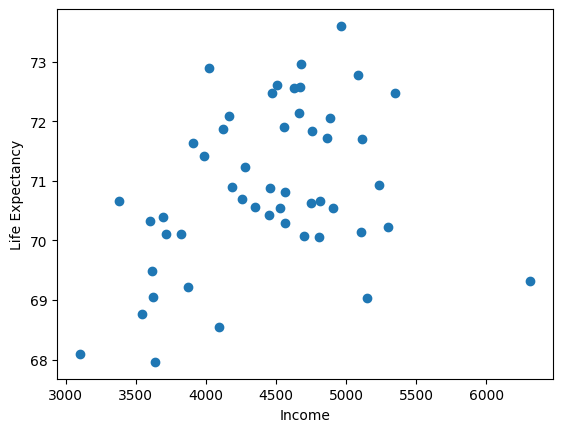

In [8]:
# Although the point in the lower right hand corner of the plot appears to be
# an outlier, we observe a positive linear relationship in the plot.

# Scatter plot of Income vs Life Expectancy
plt.scatter(df_state["Income"], df_state["Life.Exp"])
plt.xlabel("Income")
plt.ylabel("Life Expectancy")
plt.show()

## Refining the Model and Analyzing Predictions

Recall that we discussed the principle of simplicity: that is, a model with fewer variables is preferable to a model with many unnnecessary variables. Experiment with removing independent variables from the original model. Remember to use the significance of the coefficients to decide which variables to remove (remove the one with the largest "p-value" first, or the one with the "t value" closest to zero), and to remove them one at a time (this is called "backwards variable selection"). This is important due to multicollinearity issues - removing one insignificant variable may make another previously insignificant variable become significant.

You should be able to find a good model with only 4 independent variables, instead of the original 7. Which variables does this model contain?


*   Income, HS.Grad, Frost, Murder
*   HS.Grad, Population, Income, Frost
*   Frost, Murder, HS.Grad, Illiteracy
*   Population, Murder, Frost, HS.Grad


In [9]:
X = df_state[["Population", "Income", "Illiteracy", "Murder", "HS.Grad", "Frost", "Area"]]
y = df_state["Life.Exp"]

model = LinearRegression()
model.fit(X, y)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R^2 Score:", model.score(X, y))

Coefficients: [ 5.18003638e-05 -2.18042378e-05  3.38203214e-02 -3.01123170e-01
  4.89294789e-02 -5.73500110e-03 -7.38316614e-08]
Intercept: 70.94322411112931
R^2 Score: 0.7361562689089043


In [10]:
import scipy.stats as stats
def get_p_values(X, model, y):
  # Predictions
  y_pred = model.predict(X)

  # Compute residuals
  residuals = y - y_pred

  # Compute standard error of the estimate
  n, p = X.shape  # Number of observations and predictors
  sse = np.sum(residuals ** 2)  # Sum of squared errors
  mse = sse / (n - p - 1)  # Mean squared error
  se = np.sqrt(mse * np.linalg.inv(X.T @ X).diagonal())  # Standard errors

  # Compute t-statistics
  t_stats = model.coef_ / se  # Skip the intercept term

  # Compute p-values
  p_values = [2 * (1 - stats.t.cdf(np.abs(t), df=n - p - 1)) for t in t_stats]

  return list(zip(X.columns, p_values))

In [11]:
# Define predictors and response variable
X = df_state[["Population", "Income", "Illiteracy", "Murder", "HS.Grad", "Frost", "Area"]]
y = df_state["Life.Exp"]

# Fit the model
model = LinearRegression()
model.fit(X, y)

p_values = get_p_values(X, model, y)
print("R^2 Score:", model.score(X, y))

R^2 Score: 0.7361562689089043


In [12]:
# Define predictors and response variable
X = df_state[["Population", "Income", "Illiteracy", "Murder", "HS.Grad", "Frost"]]
y = df_state["Life.Exp"]

# Fit the model
model = LinearRegression()
model.fit(X, y)

p_values = get_p_values(X, model, y)
print("R^2 Score:", model.score(X, y))

R^2 Score: 0.7361439632209257


In [13]:
# Define predictors and response variable
X = df_state[["Population", "Illiteracy", "Murder", "HS.Grad", "Frost"]]
y = df_state["Life.Exp"]

# Fit the model
model = LinearRegression()
model.fit(X, y)

p_values = get_p_values(X, model, y)
print("R^2 Score:", model.score(X, y))

R^2 Score: 0.7360771901823261


In [14]:
# Define predictors and response variable
X = df_state[["Population", "Murder", "HS.Grad", "Frost"]]
y = df_state["Life.Exp"]

# Fit the model
model = LinearRegression()
model.fit(X, y)

p_values = get_p_values(X, model, y)
print("R^2 Score:", model.score(X, y))

R^2 Score: 0.7360327719572128


Observe that removing insignificant variables doesn't the R^2 Score value of the model.


Using the simplified 4 variable model that we created, let's now take a look at how our predictions compare to the actual values and identify states with the lowest life expectancies.

In [17]:
# Predictions
pred = model.predict(X)

print(df_state.iloc[np.argmin(pred)]['state.name'])

Alabama


In [18]:
# Identify state with lowest life expectancy
idx_min = df_state["Life.Exp"].idxmin()
print("State with Lowest Life Expectancy:", df_state.loc[idx_min]['state.name'])

State with Lowest Life Expectancy: South Carolina


In [19]:
# Predictions
pred = model.predict(X)

print(df_state.iloc[np.argmax(pred)]['state.name'])

Washington


In [20]:
# Identify state with lowest life expectancy
idx_max = df_state["Life.Exp"].idxmax()
print("State with Highest Life Expectancy:", df_state.loc[idx_max]['state.name'])

State with Highest Life Expectancy: Hawaii


We can also take a look at the vector of residuals (the difference between the predicted and actual values).

In [21]:
# Sort absolute residuals
idx_min = np.argmin(np.abs(y - pred))
print("State with smallest absolute error:", df_state.loc[idx_min]['state.name'])

idx_max = np.argmax(np.abs(y - pred))
print("State with largest absolute error:", df_state.loc[idx_max]['state.name'])

State with smallest absolute error: Indiana
State with largest absolute error: Hawaii


# Part 2: Climate Change
There have been many studies documenting that the average global temperature has been increasing over the last century. The consequences of a continued rise in global temperature will be dire. Rising sea levels and an increased frequency of extreme weather events will affect billions of people.

In this problem, we will attempt to study the relationship between average global temperature and several other factors.

The file climate_change.csv contains climate data from May 1983 to December 2008. The available variables include:



*   **Year: **the observation year.
*   **Month:** the observation month.
*   **Temp:** the difference in degrees Celsius between the average global temperature in that period and a reference value. This data comes from the Climatic Research Unit at the University of East Anglia.
*   **CO2, N2O, CH4, CFC.11, CFC.12:** atmospheric concentrations of carbon dioxide (CO2), nitrous oxide (N2O), methane  (CH4), trichlorofluoromethane (CCl3F; commonly referred to as CFC-11) and dichlorodifluoromethane (CCl2F2; commonly referred to as CFC-12), respectively. This data comes from the ESRL/NOAA Global Monitoring Division.
CO2, N2O and CH4 are expressed in ppmv (parts per million by volume  -- i.e., 397 ppmv of CO2 means that CO2 constitutes 397 millionths of the total volume of the atmosphere)
CFC.11 and CFC.12 are expressed in ppbv (parts per billion by volume).
*   **Aerosols:** the mean stratospheric aerosol optical depth at 550 nm. This variable is linked to volcanoes, as volcanic eruptions result in new particles being added to the atmosphere, which affect how much of the sun's energy is reflected back into space. This data is from the Godard Institute for Space Studies at NASA.
*   **TSI:** the total solar irradiance (TSI) in W/m2 (the rate at which the sun's energy is deposited per unit area). Due to sunspots and other solar phenomena, the amount of energy that is given off by the sun varies substantially with time. This data is from the SOLARIS-HEPPA project website.
*   **MEI:** multivariate El Nino Southern Oscillation index (MEI), a measure of the strength of the El Nino/La Nina-Southern Oscillation (a weather effect in the Pacific Ocean that affects global temperatures). This data comes from the ESRL/NOAA Physical Sciences Division.

## Creating Our First Model

We are interested in how changes in these variables affect future temperatures, as well as how well these variables explain temperature changes so far. To do this, first read the dataset climate_change.csv into R.

Then, split the data into a training set, consisting of all the observations up to and including 2006, and a testing set consisting of the remaining years. A training set refers to the data that will be used to build the model, and a testing set refers to the data we will use to test our predictive ability.

Next, build a linear regression model to predict the dependent variable Temp, using MEI, CO2, CH4, N2O, CFC.11, CFC.12, TSI, and Aerosols as independent variables (Year and Month should NOT be used in the model). Use the training set to build the model.

What's the model R2 (the "R-squared" value)?

In [ ]:
# Problem 2 - Climate Data
climate = pd.read_csv("climate_change.csv")
print(climate.info())

# Splitting Data
climate_train = climate[climate["Year"] <= 2006]
climate_test = climate[climate["Year"] > 2006]

# Linear Regression Model
X_climate = climate_train[["MEI", "CO2", "CH4", "N2O", "CFC-11", "CFC-12", "TSI", "Aerosols"]]
y_climate = climate_train["Temp"]

climate_model = LinearRegression()
climate_model.fit(X_climate, y_climate)
pred_climate = climate_model.predict(X_climate)

# R^2 Calculation
SSE = np.sum((pred_climate - y_climate) ** 2)
SST = np.sum((y_climate.mean() - y_climate) ** 2)
r_squared = 1 - SSE / SST
print("R-squared:", r_squared)


print("Coefficients:", list(zip(X_climate.columns, climate_model.coef_)))
print("Intercept:", climate_model.intercept_)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      308 non-null    int64  
 1   Month     308 non-null    int64  
 2   MEI       308 non-null    float64
 3   CO2       308 non-null    float64
 4   CH4       308 non-null    float64
 5   N2O       308 non-null    float64
 6   CFC-11    308 non-null    float64
 7   CFC-12    308 non-null    float64
 8   TSI       308 non-null    float64
 9   Aerosols  308 non-null    float64
 10  Temp      308 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 26.6 KB
None
R-squared: 0.7508932770523451
Coefficients: [('MEI', np.float64(0.06420531336752591)), ('CO2', np.float64(0.006457359272336446)), ('CH4', np.float64(0.00012404189575250177)), ('N2O', np.float64(-0.016528003257473757)), ('CFC-11', np.float64(-0.0066304888893797854)), ('CFC-12', np.float64(0.0038081032430232254)), ('TSI', np.float64

Let's now take a look at the p-values to see what variables are signficant. Recall that a variable is significant only if its p-value is below 0.05.

In [ ]:
get_p_values(X_climate, climate_model, y_climate)

[('MEI', np.float64(0.0)),
 ('CO2', np.float64(0.005047571506455961)),
 ('CH4', np.float64(0.8101200855318864)),
 ('N2O', np.float64(0.05421929932766445)),
 ('CFC-11', np.float64(5.632211801520626e-05)),
 ('CFC-12', np.float64(0.00020776827080415394)),
 ('TSI', np.float64(0.0)),
 ('Aerosols', np.float64(3.1468161409975437e-12))]

## Understanding the Model

Current scientific opinion is that nitrous oxide and CFC-11 are greenhouse gases: gases that are able to trap heat from the sun and contribute to the heating of the Earth. However, the regression coefficients of both the N2O and CFC-11 variables are negative, indicating that increasing atmospheric concentrations of either of these two compounds is associated with lower global temperatures.

Which of the following is the simplest correct explanation for this contradiction?
*   Climate scientists are wrong that N2O and CFC-11 are greenhouse gases - this regression analysis constitutes part of a disproof.
*   There is not enough data, so the regression coefficients being estimated are not accurate.
*   All of the gas concentration variables reflect human development - N2O and CFC.11 are correlated with other variables in the data set.

We now compute the correlations between all the variables in the training set. Recall that variables are considered highly correlated if their absolute correlation is greater than 0.7.

In [ ]:
# Correlation matrix
print(climate_train.corr())

              Year     Month       MEI       CO2       CH4       N2O  \
Year      1.000000 -0.027942 -0.036988  0.982749  0.915659  0.993845   
Month    -0.027942  1.000000  0.000885 -0.106732  0.018569  0.013632   
MEI      -0.036988  0.000885  1.000000 -0.041147 -0.033419 -0.050820   
CO2       0.982749 -0.106732 -0.041147  1.000000  0.877280  0.976720   
CH4       0.915659  0.018569 -0.033419  0.877280  1.000000  0.899839   
N2O       0.993845  0.013632 -0.050820  0.976720  0.899839  1.000000   
CFC-11    0.569106 -0.013111  0.069000  0.514060  0.779904  0.522477   
CFC-12    0.897012  0.000675  0.008286  0.852690  0.963616  0.867931   
TSI       0.170302 -0.034606 -0.154492  0.177429  0.245528  0.199757   
Aerosols -0.345247  0.014890  0.340238 -0.356155 -0.267809 -0.337055   
Temp      0.786797 -0.099857  0.172471  0.788529  0.703255  0.778639   

            CFC-11    CFC-12       TSI  Aerosols      Temp  
Year      0.569106  0.897012  0.170302 -0.345247  0.786797  
Month    -0.0

## Simplifying the Model

Given that the correlations are so high, let us focus on the N2O variable and build a model with only MEI, TSI, Aerosols and N2O as independent variables. Remember to use the training set to build the model.

We can compute the coefficient of N2O in this reduced model (how does this compare to the coefficient in the previous model with all of the variables?):



In [ ]:
# Reduced Model
X_climate2 = climate_train[["MEI", "N2O", "TSI", "Aerosols"]]
climate_model2 = LinearRegression()
climate_model2.fit(X_climate2, y_climate)
print("Reduced Model Coefficients:", list(zip(X_climate2.columns, climate_model2.coef_)))

Reduced Model Coefficients: [('MEI', np.float64(0.06418575556445434)), ('N2O', np.float64(0.025319745728983364)), ('TSI', np.float64(0.07949027967634045)), ('Aerosols', np.float64(-1.7017370668724554))]


We can also compute the model's R^2.:

In [ ]:
# R^2 Calculation
pred_climate2 = climate_model2.predict(X_climate2)
SSE = np.sum((pred_climate2 - y_climate) ** 2)
SST = np.sum((y_climate.mean() - y_climate) ** 2)
r_squared = 1 - SSE / SST
print("R-squared:", r_squared)

R-squared: 0.726132127951111
